In [28]:
import pandas as pd

In [29]:
# Data cleaning

In [30]:
df = pd.read_csv("Sample - Superstore.csv",encoding="latin1")

In [32]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [37]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df = df.drop_duplicates()

In [41]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [42]:
# convert datatypes

In [43]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [44]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [128]:
df["Year"] = df["Order Date"].dt.year

In [137]:
df.to_csv("updated_Sales_Data.csv",index=False)

In [138]:
pwd

'C:\\Users\\nikhi\\OneDrive\\Desktop\\30_Days_DA_Projects\\Projeect1'

In [127]:
# verify data cleaning 

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [47]:
df.isnull().any()

Row ID           False
Order ID         False
Order Date       False
Ship Date        False
Ship Mode        False
Customer ID      False
Customer Name    False
Segment          False
Country          False
City             False
State            False
Postal Code      False
Region           False
Product ID       False
Category         False
Sub-Category     False
Product Name     False
Sales            False
Quantity         False
Discount         False
Profit           False
dtype: bool

# Perform Business Analytics

""" The objective of this phase is to analyze business performance using sales, profit, quantity, discount, category, region, and customer data to identify trends, opportunities, and areas for improvement."""

In [95]:
# Total Sales Analysis

# KPI 1 Total Sales

In [49]:
Total_sales = df["Sales"].sum()

In [56]:
print("Total_Sales :",Total_sales)

# Purpose: To determine the overall revenue generated by the business.

Total_Sales : 2297200.8603


In [96]:
# Total Profit Analysis

# KPI 2 Total Profit

In [58]:
Total_profit = df["Profit"].sum()

In [59]:
print("Total_Profit :",Total_profit)

# Purpose: To evaluate the overall profitability of the busines

Total_Profit : 286397.0217


In [97]:
# KPI 3 Total Orders

In [98]:
Total_orders = df["Order ID"].nunique()

In [99]:
print("Total_Orders :",Total_orders)

Total_Orders : 5009


In [100]:
# KPI 4 Average Order Value

In [101]:
avg_order_val = Total_sales / Total_orders

In [103]:
print("Average Order Value :",avg_order_val)

Average Order Value : 458.6146656618087


# Phase 4: GROUP BY Analysis

In [60]:
# Sales by Category

In [62]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Purpose: To identify which product categories generate the highest sales.

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [63]:
# Profit by Category

In [67]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

#Purpose: To determine the most profitable product categories.

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [68]:
# Sales by Region

In [69]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Purpose: To compare sales performance across regions.

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [70]:
# Profit by Region

In [72]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

# Purpose: To identify the most profitable regions.

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [73]:
# Top 10 Products by Sales

In [75]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Purpose: To identify best-selling products.

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [76]:
# Top 10 Products by Profit

In [78]:
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

#Purpose: To identify the most profitable products.

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [ ]:
# Sales by Customer Segment

In [82]:
df.groupby('Segment')['Sales'].sum()

#Purpose: To analyze revenue contribution from different customer segments.

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

In [83]:
# Impact of Discount on Profit

In [84]:
# check cor-relation

In [87]:
df[['Discount','Profit']].corr()

# Purpose: To understand how discounts affect profitability.

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [88]:
# State-wise Sales Analysis

In [91]:
df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

# Purpose: To identify top-performing states based on sales.

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

In [92]:
# State-wise Profit Analysis

In [94]:
df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)

#Purpose: To identify states contributing the highest profit.

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

In [105]:
# HAVING Equivalent in Pandas

In [106]:
df.groupby('Region')['Sales'].sum().reset_index().query('Sales > 100000')

,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


In [ ]:
"""
Key Business Insights
Identify the highest revenue-generating category.
Identify the most profitable category.
Determine the best-performing region.
Identify products contributing maximum sales and profit.
Analyze the effect of discounts on profitability.
Understand customer segment performance.
Identify opportunities for business growth.
Outcome

Business Analytics transformed raw transactional data into meaningful insights that helped evaluate sales performance,
profitability, customer behavior, product demand, and regional performance. 
These insights can support strategic business decisions and improve overall business growth.

"""

# Phase 6: Create Visualizations

"""

Objective

The objective of this phase is to transform the analyzed data into graphical representations 
that make business trends, patterns, and insights easier to understand and interpret.


"""

In [107]:
# 1. Sales by Category

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

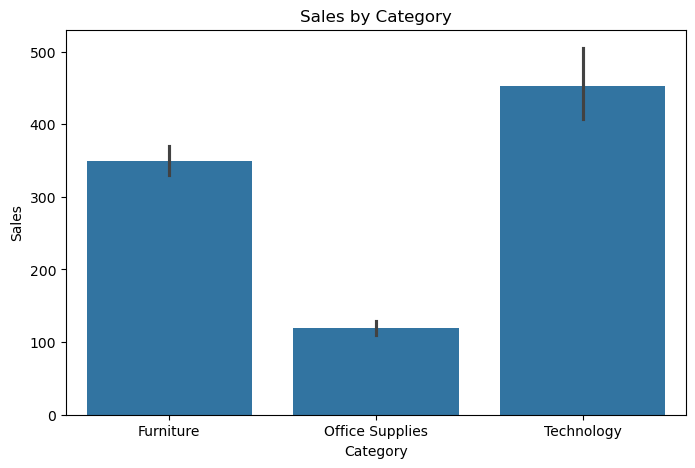

In [110]:


plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df)
plt.title('Sales by Category')
plt.show()

#Purpose: Compare sales performance across product categories.

In [111]:
# 2. Profit by Category

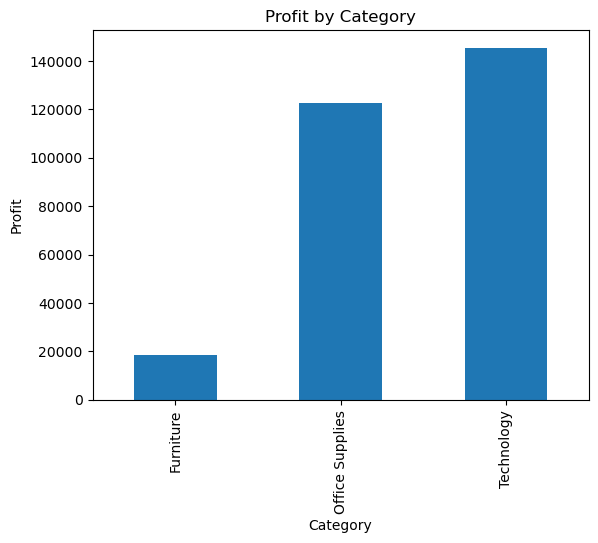

In [112]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.ylabel('Profit')
plt.show()

# Purpose: Identify the most profitable category.

In [113]:
# 3. Sales by Region

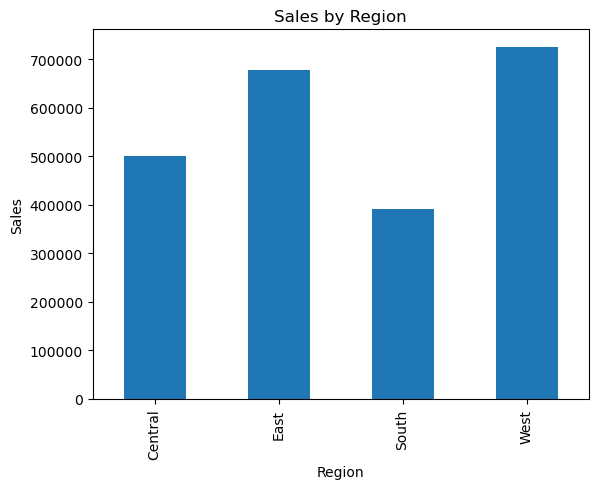

In [114]:

region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.ylabel('Sales')
plt.show()

# Purpose: Analyze regional sales performance.

In [115]:
# 4. Profit Distribution

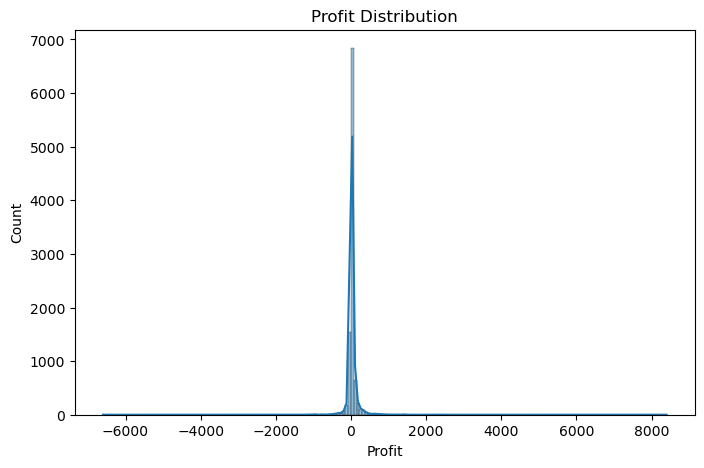

In [116]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], kde=True)
plt.title('Profit Distribution')
plt.show()

# Purpose: Understand the distribution of profits and losses.

In [117]:
# 5. Correlation Heatmap

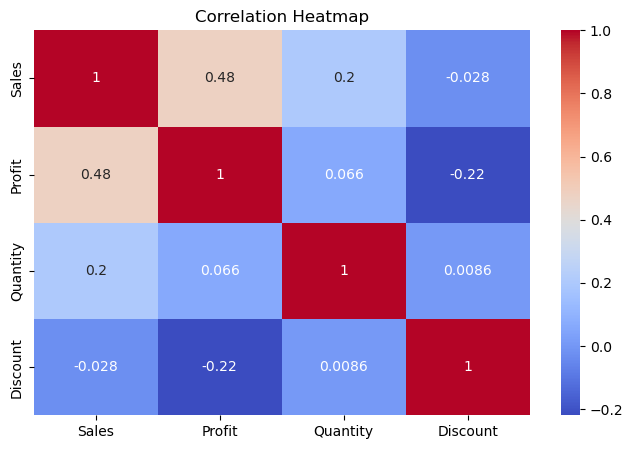

In [118]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df[['Sales','Profit','Quantity','Discount']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

# Purpose: Identify relationships between numerical variables.

In [119]:
# 6. Top 10 States by Sales

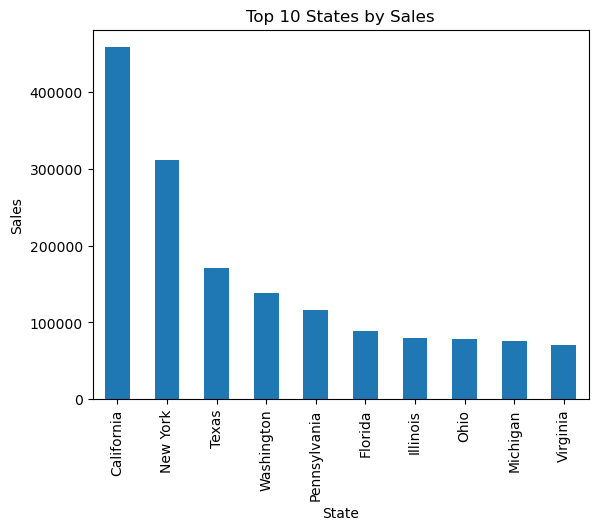

In [120]:

top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.ylabel('Sales')
plt.show()

# Purpose: Identify the highest revenue-generating states.

In [121]:
# 7. Sales by Customer Segment

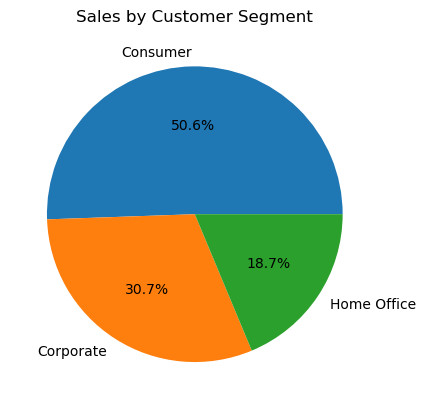

In [122]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.pie(segment_sales,
        labels=segment_sales.index,
        autopct='%1.1f%%')
plt.title('Sales by Customer Segment')
plt.show()

# Purpose: Analyze the contribution of each customer segment.

In [124]:
# 8. Discount vs Profit

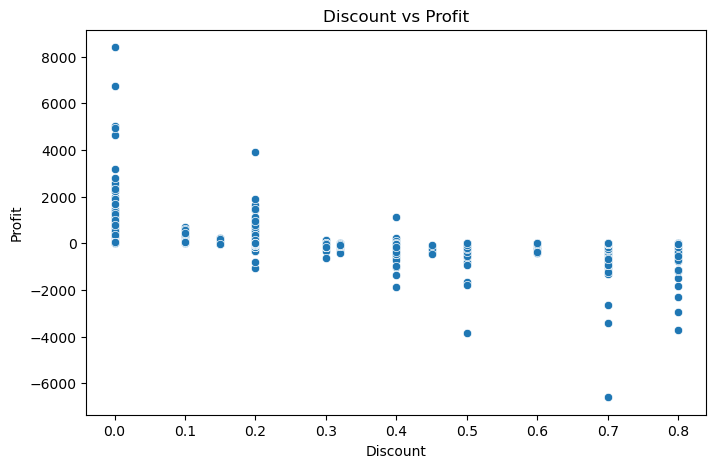

In [125]:

plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Discount vs Profit')
plt.show()

# Purpose: Examine the impact of discounts on profitability.

In [135]:
# Year-wise Sales
yearly_sales = df.groupby('Year')['Sales'].sum()

# Year-over-Year Growth (%)
yoy_growth = yearly_sales.pct_change() * 100

print(yearly_sales)
print()
print(yoy_growth)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

Year
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64


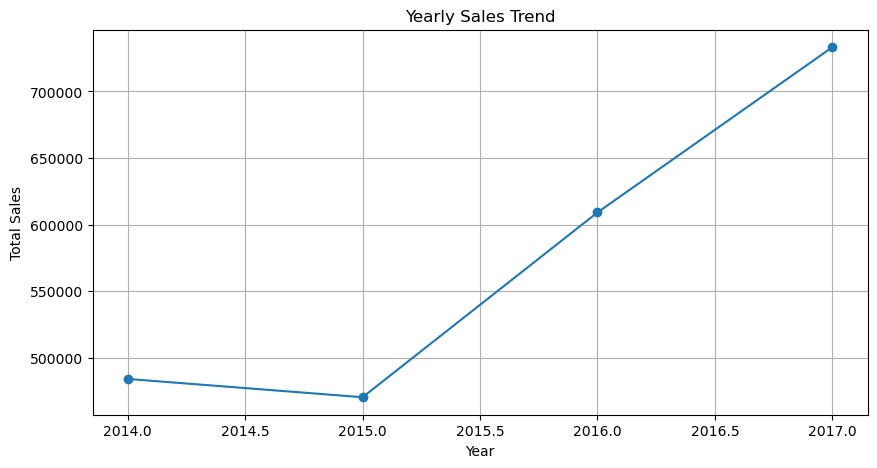

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [ ]:
"""

Key Insights from Visualizations :


Identify the highest-selling product category.
Determine the most profitable category.
Compare sales performance across regions.
Understand customer segment contributions.
Analyze the relationship between discount and profit.
Detect trends, outliers, and business opportunities.


Outcome :

Visualization techniques were used to present business data in an intuitive and meaningful manner. 
Graphical analysis helped identify sales trends, profit patterns, customer behavior, 
and regional performance, enabling better business decision-making.






"""